In [ ]:
# Cell 1: Cấu hình mô phỏng ⚙️
import torch

class SimulationConfig:
    # === 1. Cấu hình kiến trúc & Phân cấp ===
    ALGORITHM = 'hsfl_simclr'
    ANONYMITY = False            # Enable TOR-like simulation
    NUM_TIERS = 3              # Ví dụ: 3 = Client(1) + Edge(2) + Cloud(3)
    # Số lượng thực thể ở mỗi tầng (trừ tầng client) - Ví dụ cho 3 tầng
    # Tầng 2 (Edge): 5 servers, Tầng 3 (Cloud): 1 server
    ENTITIES_PER_TIER = [5, 1] 
    # Cách map client vào tầng trên (ví dụ: chia đều client cho edge)
    CLIENT_MAPPING = 'balanced' 
    GLOBAL_ROUNDS = 200        # Số vòng huấn luyện lớn (Cloud -> Edge -> Client)

    # === 2. Cấu hình SimCLR & Huấn luyện Local ===
    SIMCLR_EPOCHS_CLIENT = 5   # Số epoch huấn luyện SimCLR tại client mỗi global round
    SIMCLR_EPOCHS_EDGE = 10    # Số epoch huấn luyện SimCLR tại edge mỗi global round
    SIMCLR_EPOCHS_CLOUD = 10   # Số epoch huấn luyện SimCLR tại cloud mỗi global round
    PROJECTION_DIM = 128       # Kích thước output của projection head
    TEMPERATURE = 0.5          # Nhiệt độ cho NT-Xent loss
    
    # === 3. Cấu hình Prototype & Sample Generation ===
    # 'kmeans' hoặc 'mean_std'
    PROTOTYPE_METHOD = 'mean_std' 
    NUM_PROTOTYPES = 50        # Số prototype nếu dùng kmeans
    # 'prototypes_as_data' (đơn giản nhất) hoặc các pp phức tạp hơn (GAN, VAE...)
    SAMPLE_GENERATION_METHOD = 'gaussian_sampling' 

    # === 4. Cấu hình Huấn luyện & Đánh giá ===
    BATCH_SIZE = 128           # SimCLR thường cần batch size lớn
    LEARNING_RATE = 0.0001      # Adam thường dùng LR nhỏ
    # Tham số cho linear probing evaluation
    LINEAR_PROBE_EPOCHS = 50

    # === 5. Cấu hình hệ thống & đường dẫn ===
    CONFIG_PATH = '../configs/config.yaml'
    DATA_PATH = '../data'
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SEED = 42

config = SimulationConfig()

# --- Kiểm tra cấu hình ---
assert len(config.ENTITIES_PER_TIER) == config.NUM_TIERS - 1, "ENTITIES_PER_TIER phải có độ dài NUM_TIERS - 1"

In [24]:
# Cell 2: Tải cấu hình, dữ liệu và thiết lập cấu trúc phân cấp 📦
import yaml, torch, numpy as np, time, copy, os, collections
import matplotlib.pyplot as plt
from torch import nn
from torch.optim import Adam
# Sẽ import prepare_data từ file .py thay vì notebook
import sys
sys.path.append(os.path.abspath(os.path.join('..')))
from src.dataset_preparation import prepare_data 
import torch.nn.functional as F
# from src.monitoring_utils import ResourceMonitor, shutdown_pynvml # Tạm thời bỏ qua monitor

# --- Setup & Load Config ---
torch.manual_seed(config.SEED); np.random.seed(config.SEED)
print(f"Đang đọc file cấu hình từ: {config.CONFIG_PATH}")
with open(config.CONFIG_PATH, 'r') as f: loaded_config = yaml.safe_load(f)
data_params = loaded_config['data_config']
# Ghi đè BATCH_SIZE vì SimCLR cần batch size khác
# data_params['batch_size'] = config.BATCH_SIZE # Use BATCH_SIZE from SimConfig
print(f"Đã tải cấu hình dữ liệu: {data_params}")

# --- Prepare Data ---
client_loaders, test_loader, class_names = prepare_data(
    data_path=config.DATA_PATH,
    batch_size=config.BATCH_SIZE, # Use SimConfig BATCH_SIZE here
    seed=config.SEED,
    **data_params
)
total_num_clients = len(client_loaders)
num_classes = len(class_names)
print(f"\nĐã khởi tạo dữ liệu cho {total_num_clients} client.")
print(f"Sử dụng thiết bị: {config.DEVICE}")

# --- Thiết lập cấu trúc phân cấp ---
# entities_map[tier_idx] = list of entity_ids in that tier
# client_parent_map[client_id] = (parent_tier_idx, parent_entity_id)
# entity_children_map[(tier_idx, entity_id)] = list of children_ids (clients or lower tier entities)

entities_map = collections.defaultdict(list)
client_parent_map = {}
entity_children_map = collections.defaultdict(list)

# Tầng 1 (Clients)
entities_map[0] = list(range(total_num_clients))

# Map clients to Tier 2 (Edges)
num_entities_tier2 = config.ENTITIES_PER_TIER[0]
entities_map[1] = list(range(num_entities_tier2))
# Ensure array_split handles edge case where num_clients < num_entities_tier2 if needed
client_indices_per_edge = np.array_split(np.arange(total_num_clients), num_entities_tier2)

for edge_id, client_indices in enumerate(client_indices_per_edge):
    entity_children_map[(1, edge_id)] = list(client_indices) # Edge's children are clients
    for client_id in client_indices:
        client_parent_map[client_id] = (1, edge_id) # Client's parent is an edge

# Map Tier 2 (Edges) to Tier 3 (Cloud) - Giả sử chỉ có 1 Cloud
if config.NUM_TIERS > 2:
     num_entities_tier3 = config.ENTITIES_PER_TIER[1] # Thường là 1
     entities_map[2] = list(range(num_entities_tier3))
     # Giả sử tất cả edge kết nối lên cloud 0
     entity_children_map[(2, 0)] = entities_map[1] # Cloud's children are edges
     # Parent mapping for edges (Tier 2 entities)
     for edge_id in entities_map[1]:
          # Map edge to its parent cloud (assuming cloud 0)
          # This map isn't strictly needed if only 1 cloud, but good practice
          # client_parent_map[(1, edge_id)] = (2, 0) # Example if needed later
          pass # CORRECTED: Added pass for the loop

print("\nCấu trúc phân cấp:")
print(f"  - Tầng 1 (Clients): {total_num_clients}")
print(f"  - Tầng 2 (Edges): {num_entities_tier2}")
# (Optional: Print more details)
# for i, group in enumerate(client_groups_for_edges):
#     print(f"    - Edge {i}: Phục vụ clients {edge_client_indices[i]}")
if config.NUM_TIERS > 2: print(f"  - Tầng 3 (Cloud): {num_entities_tier3}")

Đang đọc file cấu hình từ: ../configs/config.yaml
Đã tải cấu hình dữ liệu: {'dataset_name': 'cifar10', 'distribution_mode': 'iid', 'num_clients': 50, 'shards_per_client': 2, 'dirichlet_alpha': 0.5}

Đã khởi tạo dữ liệu cho 50 client.
Sử dụng thiết bị: cuda

Cấu trúc phân cấp:
  - Tầng 1 (Clients): 50
  - Tầng 2 (Edges): 5
  - Tầng 3 (Cloud): 1


In [25]:
# Cell 3: Các thành phần SimCLR 🧩
from torchvision import transforms

# --- Data Augmentation ---
def get_simclr_transforms(input_size=32):
    # Augmentations mạnh cho SimCLR
    return transforms.Compose([
        # === THÊM DÒNG NÀY ===
        transforms.ToPILImage(), 
        # =======================
        transforms.RandomResizedCrop(size=input_size, scale=(0.2, 1.0)), # Thêm scale cho crop tốt hơn
        transforms.RandomHorizontalFlip(),
        transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
        transforms.RandomGrayscale(p=0.2),
        # RandomApply([transforms.GaussianBlur(kernel_size=input_size//10*2+1, sigma=(0.1, 2.0))], p=0.5), # GaussianBlur nếu cần
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Chuẩn hóa ImageNet
    ])

# --- Projection Head ---
class ProjectionMLP(nn.Module):
    def __init__(self, in_features, hidden_dim=512, out_dim=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )
    def forward(self, x):
        return self.mlp(x)

# --- NT-Xent Loss ---
def nt_xent_loss(z_i, z_j, temperature):
    batch_size = z_i.shape[0]
    z = torch.cat((z_i, z_j), dim=0)
    z = F.normalize(z, dim=1)
    
    sim_matrix = torch.mm(z, z.T) / temperature
    # Loại bỏ đường chéo (tự so sánh)
    sim_matrix = sim_matrix - torch.eye(2 * batch_size, device=z.device) * 1e5 
    
    labels = torch.arange(2 * batch_size, device=z.device)
    # Positive pair cho z_i là z_j (ở vị trí i + batch_size)
    # Positive pair cho z_j là z_i (ở vị trí j - batch_size)
    labels = (labels + batch_size) % (2 * batch_size) 
    
    loss = F.cross_entropy(sim_matrix, labels)
    return loss

In [26]:
# Cell 4: Định nghĩa các phần mô hình 🧠
from torchvision.models import resnet18, ResNet18_Weights
import collections

def create_hsfl_resnet_parts(num_tiers=3, input_sample_shape=(2, 3, 32, 32)):
    """Chia ResNet18, tính toán flattened dims VÀ unflattened shapes."""
    base_model = resnet18(weights=ResNet18_Weights.DEFAULT)
    modules = list(base_model.children())[:-1]
    model_parts = []; flattened_feature_dims = []; unflattened_shapes = [] # <-- Thêm list này
    dummy_input = torch.randn(*input_sample_shape)

    if num_tiers == 3:
        client_part = nn.Sequential(*modules[:5])
        edge_part = nn.Sequential(*modules[5:7])
        cloud_part = nn.Sequential(*modules[7], nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(1))
        model_parts = [client_part, edge_part, cloud_part]

        # Chạy dummy pass
        with torch.no_grad():
            out1 = client_part(dummy_input)
            unflattened_shapes.append(out1.shape[1:]) # Lưu lại [C, H, W]
            flat_dim1 = nn.Flatten(1)(out1).shape[1]
            flattened_feature_dims.append(flat_dim1)

            out2 = edge_part(out1)
            unflattened_shapes.append(out2.shape[1:]) # Lưu lại [C, H, W]
            flat_dim2 = nn.Flatten(1)(out2).shape[1]
            flattened_feature_dims.append(flat_dim2)

            out3 = cloud_part(out2) # cloud_part đã bao gồm flatten
            # Tầng cuối không có unflattened shape tiếp theo rõ ràng, có thể để None hoặc shape cuối
            unflattened_shapes.append(None) # Hoặc out3.shape[1:] nếu cần
            flat_dim3 = out3.shape[1]
            flattened_feature_dims.append(flat_dim3)

        print(f"Kích thước feature (flattened): {flattened_feature_dims}")
        print(f"Shape Output (Unflattened): {unflattened_shapes}") # In ra shape [C,H,W]

    else: raise NotImplementedError("Chỉ hỗ trợ 3 tầng.")
    # Trả về cả unflattened_shapes
    return model_parts, flattened_feature_dims, unflattened_shapes # <-- Sửa giá trị trả về

# --- Tạo mô hình, projection heads VÀ LƯU SHAPES ---
input_size = 64 if data_params['dataset_name'] == 'tiny_imagenet' else 32
hsfl_model_parts, feature_dims, unflattened_output_shapes = create_hsfl_resnet_parts( # <-- Nhận thêm shapes
    config.NUM_TIERS, input_sample_shape=(2, 3, input_size, input_size)
)

# --- Khởi tạo instances (Giữ nguyên) ---
# ... (Code khởi tạo models, projections, optimizers giữ nguyên) ...
# --- Khởi tạo instances (SỬ DỤNG feature_dims ĐÃ SỬA) ---
models = collections.defaultdict(list)
projections = collections.defaultdict(list)
optimizers = collections.defaultdict(list)

# Tầng 1 (Clients)
print(f"Khởi tạo {total_num_clients} models/projections/optimizers cho Tầng 1 (Clients)...")
for _ in range(total_num_clients):
    model = copy.deepcopy(hsfl_model_parts[0]).to(config.DEVICE)
    proj = ProjectionMLP(feature_dims[0], out_dim=config.PROJECTION_DIM).to(config.DEVICE) # Sử dụng flattened dim
    optimizer = Adam(list(model.parameters()) + list(proj.parameters()), lr=config.LEARNING_RATE)
    models[0].append(model)
    projections[0].append(proj)
    optimizers[0].append(optimizer)

# Các tầng cao hơn (Shared)
for tier_idx in range(1, config.NUM_TIERS):
    num_entities = len(entities_map[tier_idx])
    print(f"Khởi tạo {num_entities} model(s)/projections/optimizers cho Tầng {tier_idx+1}...")
    for _ in range(num_entities):
        model = copy.deepcopy(hsfl_model_parts[tier_idx]).to(config.DEVICE)
        proj = ProjectionMLP(feature_dims[tier_idx], out_dim=config.PROJECTION_DIM).to(config.DEVICE) # Sử dụng flattened dim
        optimizer = Adam(list(model.parameters()) + list(proj.parameters()), lr=config.LEARNING_RATE)
        models[tier_idx].append(model)
        projections[tier_idx].append(proj)
        optimizers[tier_idx].append(optimizer)

# Lấy transformation cho SimCLR
simclr_transforms = get_simclr_transforms(input_size=input_size) # Pass correct input size

Kích thước feature (flattened): [4096, 1024, 512]
Shape Output (Unflattened): [torch.Size([64, 8, 8]), torch.Size([256, 2, 2]), None]
Khởi tạo 50 models/projections/optimizers cho Tầng 1 (Clients)...
Khởi tạo 5 model(s)/projections/optimizers cho Tầng 2...
Khởi tạo 1 model(s)/projections/optimizers cho Tầng 3...


In [27]:
# Cell 5: Các hàm trợ giúp (Prototype, Sample Gen, SimCLR Loop, Eval) 🛠️
from sklearn.cluster import KMeans
from tqdm import tqdm # Cho progress bar
from torch.utils.data import DataLoader, TensorDataset # Added TensorDataset explicitly
import torch.nn as nn
import torch.nn.functional as F # Ensure F is imported
import torch.optim as optim # Ensure optim is imported if using optim.Adam
import numpy as np
import torch

# --- Helper to calculate tensor size ---
def calculate_tensor_size_mb(data_to_measure):
    """Calculates the size of a tensor or a dictionary of tensors in Megabytes."""
    total_size_mb = 0
    if data_to_measure is None: return 0
    elif isinstance(data_to_measure, torch.Tensor):
        total_size_mb = data_to_measure.element_size() * data_to_measure.nelement() / (1024**2)
    elif isinstance(data_to_measure, dict):
        for key, tensor in data_to_measure.items():
            if isinstance(tensor, torch.Tensor):
                total_size_mb += tensor.element_size() * tensor.nelement() / (1024**2)
    else: print(f"Warn: Cannot calc size for {type(data_to_measure)}.")
    return total_size_mb

# --- Prototype Calculation (Revised Logic) ---
@torch.no_grad()
def compute_prototypes(model, data_loader, method='kmeans', k=50):
    """Computes prototypes or statistics by running data through the provided model."""
    if model is None:
         print("Error: Model is None in compute_prototypes.")
         return None
    model.eval() # Ensure model is in evaluation mode
    all_features_flat_list = []
    flattener = nn.Flatten(1).to(config.DEVICE)

    for i, batch_data in enumerate(data_loader):
        # Extract the data tensor
        if isinstance(batch_data, (list, tuple)):
            data = batch_data[0].to(config.DEVICE)
        else:
            data = batch_data.to(config.DEVICE)

        try:
            # --- ALWAYS run the model ---
            # Input 'data' could be raw images (for client) or reshaped features (for edge/cloud)
            # The calling code needs to ensure 'data' has the correct shape for 'model'
            if data.dim() < 3 or data.dim() > 4: # Basic check for image-like tensors
                 # If input is already flat features but model expects 4D (conv), this will error here.
                 # This indicates the calling code needs to reshape the input BEFORE calling compute_prototypes
                 # OR that the model provided is wrong (e.g., providing edge model for client data).
                 print(f"      [compute_prototypes BATCH {i}] WARN: Input dim {data.dim()} unexpected for model {type(model).__name__}. Trying forward pass...")
                 # If this warning appears followed by a conv2d error, the input data shape is wrong.

            features = model(data) # Run data through the model of the CURRENT tier
            features_flat = flattener(features) # Flatten the OUTPUT of the current tier's model
            all_features_flat_list.append(features_flat.detach().cpu().numpy())
            # --------------------------

        except Exception as e:
            print(f"  Error during model forward/flatten in compute_prototypes: {e}. Input shape: {data.shape}. Skip batch.")
            continue # Skip to next batch

    # --- Aggregate features and compute prototypes/stats ---
    if not all_features_flat_list:
        print("Warn: No features collected for prototypes."); return None

    try:
        all_features_flat = np.concatenate(all_features_flat_list, axis=0)
    except ValueError as e:
        print(f"Error concatenating feature arrays: {e}. Check feature shapes."); return None

    num_samples = all_features_flat.shape[0]
    if num_samples < k and method == 'kmeans':
         print(f"Warn: Samples ({num_samples}) < k ({k}). Reducing k."); k = max(1, num_samples)

    if method == 'kmeans':
        # ... (KMeans logic remains the same) ...
        if k <= 0: print("Warn: k=0 KMeans."); return None
        if num_samples == 0: print("Warn: No features KMeans."); return None
        kmeans = KMeans(n_clusters=k, random_state=config.SEED, n_init='auto', verbose=0)
        try: kmeans.fit(all_features_flat); return torch.tensor(kmeans.cluster_centers_, dtype=torch.float32)
        except Exception as e: print(f"Error KMeans fit: {e}. Input shape: {all_features_flat.shape}"); return None
    elif method == 'mean_std':
        # ... (Mean/Std logic remains the same) ...
        if num_samples == 0: print("Warn: No features mean/std."); return None
        mean = np.mean(all_features_flat, axis=0); std = np.std(all_features_flat, axis=0)
        if mean.shape != std.shape: std = np.zeros_like(mean)
        return {'mean': torch.tensor(mean, dtype=torch.float32), 'std': torch.tensor(std, dtype=torch.float32)}
    else:
        raise ValueError("Invalid prototype method.")

# --- Sample Generation (No changes needed from previous version) ---
def generate_samples(prototypes_or_stats, num_samples, method='prototypes_as_data'):
    if prototypes_or_stats is None: print("Warning: Protos/stats None."); return None
    if method == 'prototypes_as_data':
        if not isinstance(prototypes_or_stats, torch.Tensor) or prototypes_or_stats.numel()==0: print("Warn: Invalid protos."); return None
        num_available = len(prototypes_or_stats);
        if num_available == 0: print("Warn: No protos."); return None
        indices = np.random.choice(num_available, num_samples, replace=True); return prototypes_or_stats[indices]
    elif method == 'gaussian_sampling':
        if not isinstance(prototypes_or_stats, list) or not prototypes_or_stats: print("Warn: Invalid stats list."); return None
        all_samples = []
        num_distributions = len(prototypes_or_stats); samples_per_dist = num_samples // num_distributions; remainder = num_samples % num_distributions
        for i, stats_dict in enumerate(prototypes_or_stats):
            if not isinstance(stats_dict, dict) or 'mean' not in stats_dict or 'std' not in stats_dict: print(f"  Warn: Skip invalid stats dict."); continue
            mean = stats_dict['mean']; std = stats_dict['std']
            if mean is None or std is None: print(f"  Warn: Skip None mean/std."); continue
            n_samples_this = samples_per_dist + (1 if i < remainder else 0);
            if n_samples_this == 0: continue
            samples = torch.randn(n_samples_this, len(mean), device=mean.device) * std.clamp(min=1e-6) + mean; all_samples.append(samples)
        if not all_samples: print("Warn: Gaussian sampling no samples."); return None
        return torch.cat(all_samples, dim=0)
    else: raise ValueError("Invalid sample gen method.")

# --- SimCLR Training Loop (No changes needed from previous version) ---
def simclr_train_loop(model, projection, optimizer, data_source, epochs, is_real_data=True, expected_input_shape=None):
    model.train(); projection.train(); losses = []; flattener = nn.Flatten(1).to(config.DEVICE)
    for epoch in range(epochs):
        epoch_loss = 0.0; num_batches = 0
        if is_real_data:
            data_iterator = tqdm(data_source, desc=f"SimCLR Ep {epoch+1}/{epochs}", leave=False); num_batches = len(data_source)
        else: # Generated Features
            if data_source is None or data_source.numel() == 0: print(f"  Skip Ep {epoch+1}: No data."); continue
            pseudo_dataset = TensorDataset(data_source) # Use TensorDataset
            pseudo_loader = DataLoader(pseudo_dataset, batch_size=config.BATCH_SIZE, shuffle=True)
            data_iterator = tqdm(pseudo_loader, desc=f"SimCLR Ep {epoch+1}/{epochs}", leave=False); num_batches = len(pseudo_loader)
        if num_batches == 0: print(f"  Skip Ep {epoch+1}: Empty loader."); continue
        for batch in data_iterator:
            optimizer.zero_grad()
            try:
                if is_real_data:
                    images, _ = batch # images is a Tensor [B, C, H, W]
                    # Directly pass Tensors to simclr_transforms (which should start with ToPILImage)
                    img1 = torch.stack([simclr_transforms(img) for img in images]).to(config.DEVICE)
                    img2 = torch.stack([simclr_transforms(img) for img in images]).to(config.DEVICE)
                else: # Generated Features - Reshape needed
                    features = batch[0].to(config.DEVICE)
                    current_batch_size = features.shape[0]
                    if expected_input_shape is None: raise ValueError("expected_input_shape required if is_real_data=False")
                    try: reshaped_features = features.view(current_batch_size, *expected_input_shape)
                    except RuntimeError as e: print(f"  Error reshaping: {e}. Skip batch."); continue
                    noise1 = torch.randn_like(reshaped_features) * 0.01; noise2 = torch.randn_like(reshaped_features) * 0.01
                    img1 = reshaped_features + noise1; img2 = reshaped_features + noise2

                # Forward pass
                h1 = model(img1); h2 = model(img2);
                if h1.dim() > 2: h1_flat = flattener(h1); h2_flat = flattener(h2)
                else: h1_flat, h2_flat = h1, h2
                z1 = projection(h1_flat); z2 = projection(h2_flat)
                loss = nt_xent_loss(z1, z2, config.TEMPERATURE); loss.backward(); optimizer.step()
                epoch_loss += loss.item(); data_iterator.set_postfix(loss=loss.item())
            except Exception as e: print(f"  Error SimCLR batch: {e}. Skip."); continue
        avg_loss = epoch_loss / max(num_batches, 1); losses.append(avg_loss)
    return losses

# --- Linear Probing Evaluation (No changes needed) ---
@torch.no_grad()
def encode_data(all_models, data_loader):
    for m in all_models: m.eval()
    all_features, all_labels = [], []
    for data_batch in tqdm(data_loader, desc="Encoding data", leave=False):
        if isinstance(data_batch, (list, tuple)): data = data_batch[0].to(config.DEVICE); labels = data_batch[1]
        else: data = data_batch.to(config.DEVICE); labels = None # Handle case without labels if needed
        features = data
        try:
            for model in all_models: features = model(features)
            all_features.append(features.detach().cpu())
            if labels is not None: all_labels.append(labels.cpu())
        except Exception as e: print(f"  Error encoding batch: {e}. Skip."); continue
    if not all_features: return None, None
    final_features = torch.cat(all_features); final_labels = torch.cat(all_labels) if all_labels else None
    return final_features, final_labels

def evaluate_linear_probe(train_features, train_labels, test_features, test_labels):
    if train_features is None or train_labels is None or test_features is None or test_labels is None: print("Linear Probe skipped: Missing data."); return 0.0
    input_dim = train_features.shape[1]; global num_classes
    linear_clf = nn.Linear(input_dim, num_classes).to(config.DEVICE); clf_optimizer = Adam(linear_clf.parameters(), lr=0.01); clf_criterion = nn.CrossEntropyLoss()
    train_dataset = TensorDataset(train_features, train_labels) # Use TensorDataset
    train_loader = DataLoader(train_dataset, batch_size=min(512, len(train_dataset)), shuffle=True)
    print("Training Linear Probe..."); linear_clf.train()
    for epoch in range(config.LINEAR_PROBE_EPOCHS):
        for features, labels in train_loader:
            features, labels = features.to(config.DEVICE), labels.to(config.DEVICE); clf_optimizer.zero_grad()
            logits = linear_clf(features); loss = clf_criterion(logits, labels); loss.backward(); clf_optimizer.step()
    linear_clf.eval(); correct = 0; total = 0
    test_dataset = TensorDataset(test_features, test_labels); test_loader_probe = DataLoader(test_dataset, batch_size=512)
    with torch.no_grad():
         for features, labels in test_loader_probe:
              features, labels = features.to(config.DEVICE), labels.to(config.DEVICE)
              logits = linear_clf(features); preds = logits.argmax(dim=1); correct += (preds == labels).sum().item(); total += labels.size(0)
    accuracy = 100. * correct / total if total > 0 else 0.0; print(f"Linear Probe Test Accuracy: {accuracy:.2f}%"); return accuracy

# --- get_entity_id function (No changes needed) ---
def get_entity_id(tier_idx, client_id):
    if tier_idx == 0: return client_id
    elif tier_idx == 1:
        if client_id in client_parent_map:
            parent_tier, parent_id = client_parent_map[client_id]
            if parent_tier == 1: return parent_id
            else: print(f"Warn: Client {client_id} parent not Tier 2."); return 0
        else: print(f"Warn: Client {client_id} not in map."); return 0
    else: # Higher tiers (Cloud)
        num_entities_this_tier = len(entities_map.get(tier_idx, []))
        if num_entities_this_tier == 1: return 0
        else: print(f"Warn: Multiple entities Tier {tier_idx+1}. Using 0."); return 0

In [28]:
# Cell 6: Vòng lặp huấn luyện chính (HSFL-SimCLR + TOR) 🚀
import collections
import time
import random
import torch
import numpy as np
from tqdm import tqdm # Ensure tqdm is imported
from torch.utils.data import DataLoader, TensorDataset # Ensure these are imported

# Initialize history dictionary with all keys
history = {
    'rounds': [],
    'accuracy': [],
    'comm_cost': [],
    'comp_cost': [], # Placeholder for computation cost
    'ram_usage': [], # Placeholder for RAM usage
    'gpu_usage': []  # Placeholder for GPU usage
}

print(f"\n--- BẮT ĐẦU MÔ PHỎNG: {config.ALGORITHM.upper()} ---")

# --- Global Training Loop ---
for current_round in range(1, config.GLOBAL_ROUNDS + 1):
    # Conditionally clear cache only if device is CUDA
    if config.DEVICE.type == 'cuda':
        torch.cuda.empty_cache() # Clear cache at the start of the round

    round_start_time = time.time()
    print(f"\n--- Global Round {current_round}/{config.GLOBAL_ROUNDS} ---")
    comm_cost_round = 0.0 # Track communication cost for this round
    round_comp_cost = 0.0 # Track computation cost (estimated)
    # round_peak_ram = 0.0 # Uncomment if using ResourceMonitor
    # round_peak_gpu = 0.0 # Uncomment if using ResourceMonitor

    # --- Tier 1: Client SimCLR Training & Prototype Calculation ---
    print("  Tầng 1 (Client): Huấn luyện SimCLR...")
    client_outputs_buffer = [] # Store {'parent_id': id, 'data': proto_or_stat}
    client_train_start_time = time.time()
    for client_id in tqdm(range(total_num_clients), desc="Client Training", leave=False):
        # Conditionally clear cache
        if config.DEVICE.type == 'cuda' and client_id > 0 and client_id % 10 == 0:
             torch.cuda.empty_cache() # Clear cache periodically

        model = models[0][client_id]; proj = projections[0][client_id]; optimizer = optimizers[0][client_id]
        loader = client_loaders[client_id]

        # Train using SimCLR on local data (simclr_train_loop moves data internally)
        simclr_train_loop(model, proj, optimizer, loader, config.SIMCLR_EPOCHS_CLIENT, is_real_data=True)

        # Compute prototypes/stats after training (compute_prototypes moves data internally)
        proto_or_stat = compute_prototypes(
            model,
            loader,
            config.PROTOTYPE_METHOD,
            k=config.NUM_PROTOTYPES
        )
        if proto_or_stat is not None:
            parent_tier, parent_id = client_parent_map.get(client_id, (None, None))
            if parent_id is not None:
                 client_outputs_buffer.append({'parent_id': parent_id, 'data': proto_or_stat})
            else:
                 print(f"  Warn: Client {client_id} has no parent mapping. Skipping output.")
        # else: prototype calculation failed
    round_comp_cost += (time.time() - client_train_start_time)

    # --- Communication: Client -> Edge (Anonymized) ---
    print("  Giao tiếp: Client -> Edge (Anonymized)...")
    edge_received_data_anon = collections.defaultdict(list)
    for output in client_outputs_buffer:
        parent_id = output['parent_id']; data = output['data']
        edge_received_data_anon[parent_id].append(data)
        comm_cost_round += calculate_tensor_size_mb(data) # Size calculation works on CPU/GPU tensors

    edge_received_data = collections.defaultdict(list)
    for edge_id, data_list in edge_received_data_anon.items():
        if config.ANONYMITY: random.shuffle(data_list)
        edge_received_data[edge_id] = data_list

    # --- Tier 2: Edge Sample Generation & SimCLR Training ---
    print(f"  Tầng 2 (Edge): Sample Generation & SimCLR Training...")
    edge_outputs_buffer = []
    edge_train_start_time = time.time()
    for edge_id in tqdm(entities_map[1], desc="Edge Training", leave=False):
         if config.DEVICE.type == 'cuda' and edge_id > 0 and edge_id % 5 == 0:
              torch.cuda.empty_cache()
         if not edge_received_data[edge_id]:
             print(f"  Skipping Edge {edge_id}: No data received."); edge_outputs_buffer.append(None); continue

         # Prepare data_for_sampling (already handled different types)
         data_for_sampling = None; received_list = edge_received_data[edge_id]
         # ... (logic to create data_for_sampling based on PROTOTYPE_METHOD) ...
         if config.PROTOTYPE_METHOD == 'kmeans':
             valid_protos = [p for p in received_list if isinstance(p, torch.Tensor)]
             if valid_protos:
                 try: data_for_sampling = torch.cat(valid_protos, dim=0)
                 except Exception as e: print(f"  Error concat KMeans Edge {edge_id}: {e}. Skip."); edge_outputs_buffer.append(None); continue
             else: print(f"  Warn: Edge {edge_id} no valid KMeans."); edge_outputs_buffer.append(None); continue
         elif config.PROTOTYPE_METHOD == 'mean_std':
             all_means = [d['mean'].unsqueeze(0) for d in received_list if isinstance(d, dict) and 'mean' in d and isinstance(d['mean'], torch.Tensor)]
             if all_means:
                 try: data_for_sampling = torch.cat(all_means, dim=0)
                 except Exception as e: print(f"  Error concat Means Edge {edge_id}: {e}. Skip."); edge_outputs_buffer.append(None); continue
             else: print(f"  Warn: Edge {edge_id} no valid Means."); edge_outputs_buffer.append(None); continue
         else: raise ValueError(f"Invalid PROTOTYPE_METHOD: {config.PROTOTYPE_METHOD}")

         if data_for_sampling is None or data_for_sampling.numel() == 0: print(f"  Warn: No sampling data Edge {edge_id}. Skip."); edge_outputs_buffer.append(None); continue

         # Generate Samples
         num_samples = data_for_sampling.shape[0] * 1000
         input_for_gen = received_list if config.SAMPLE_GENERATION_METHOD=='gaussian_sampling' else data_for_sampling
         gen_features = generate_samples(input_for_gen, num_samples, config.SAMPLE_GENERATION_METHOD)

         if gen_features is None: print(f"  Warn: Sample gen failed Edge {edge_id}. Skip."); edge_outputs_buffer.append(None); continue
         gen_features = gen_features.to(config.DEVICE) # Move generated samples to device

         # Train Edge SimCLR (simclr_train_loop moves data internally)
         model = models[1][edge_id]; proj = projections[1][edge_id]; optimizer = optimizers[1][edge_id]
         expected_shape_for_edge_input = unflattened_output_shapes[0]
         simclr_train_loop(model, proj, optimizer, gen_features, config.SIMCLR_EPOCHS_EDGE,
                           is_real_data=False, expected_input_shape=expected_shape_for_edge_input)

         # Compute Edge Prototypes (compute_prototypes moves data internally)
         reshaped_gen_features_for_proto = None
         try: reshaped_gen_features_for_proto = gen_features.view(gen_features.shape[0], *expected_shape_for_edge_input)
         except RuntimeError as e: print(f"  Error reshaping for Edge {edge_id} proto calc: {e}.")
         if reshaped_gen_features_for_proto is not None:
              pseudo_ds = TensorDataset(reshaped_gen_features_for_proto); pseudo_loader = DataLoader(pseudo_ds, batch_size=config.BATCH_SIZE)
              proto_or_stat = compute_prototypes(model, pseudo_loader, config.PROTOTYPE_METHOD, k=config.NUM_PROTOTYPES)
              if proto_or_stat is not None: edge_outputs_buffer.append({'parent_id': 0, 'data': proto_or_stat})
              else: edge_outputs_buffer.append(None)
         else: edge_outputs_buffer.append(None)
    round_comp_cost += (time.time() - edge_train_start_time)

    # --- Communication: Edge -> Cloud (Anonymized) ---
    if config.NUM_TIERS > 2:
        print("  Communication: Edge -> Cloud (Anonymized)...")
        cloud_received_data_anon = []
        for output in edge_outputs_buffer:
             if output is not None:
                 data = output['data']
                 if data is not None:
                     cloud_received_data_anon.append(data); comm_cost_round += calculate_tensor_size_mb(data)
        if config.ANONYMITY: random.shuffle(cloud_received_data_anon)
        cloud_received_data = cloud_received_data_anon

        # --- Tier 3: Cloud Training ---
        print(f"  Tier 3 (Cloud): Sample Generation & SimCLR Training...")
        cloud_train_start_time = time.time()
        if cloud_received_data:
            data_for_sampling_cloud = None
            # ... (logic to create data_for_sampling_cloud) ...
            if config.PROTOTYPE_METHOD == 'kmeans':
                 valid_protos = [p for p in cloud_received_data if isinstance(p, torch.Tensor)]
                 if valid_protos:
                     try: data_for_sampling_cloud = torch.cat(valid_protos, dim=0)
                     except Exception as e: print(f"  Error concat KMeans Cloud: {e}")
                 else: print(f"  Warn: Cloud no valid KMeans.")
            elif config.PROTOTYPE_METHOD == 'mean_std':
                 all_means = [d['mean'].unsqueeze(0) for d in cloud_received_data if isinstance(d, dict) and 'mean' in d and isinstance(d['mean'], torch.Tensor)]
                 if all_means:
                     try: data_for_sampling_cloud = torch.cat(all_means, dim=0)
                     except Exception as e: print(f"  Error concat Means Cloud: {e}")
                 else: print(f"  Warn: Cloud no valid Means.")

            if data_for_sampling_cloud is not None and data_for_sampling_cloud.numel() > 0:
                 num_samples = data_for_sampling_cloud.shape[0] * 1000
                 input_for_gen_cloud = cloud_received_data if config.SAMPLE_GENERATION_METHOD=='gaussian_sampling' else data_for_sampling_cloud
                 gen_features_cloud = generate_samples(input_for_gen_cloud, num_samples, config.SAMPLE_GENERATION_METHOD)
                 if gen_features_cloud is not None:
                     gen_features_cloud = gen_features_cloud.to(config.DEVICE) # Move generated samples
                     cloud_model = models[2][0]; cloud_proj = projections[2][0]; cloud_optimizer = optimizers[2][0]
                     expected_shape_for_cloud_input = unflattened_output_shapes[1]
                     # simclr_train_loop moves data internally
                     simclr_train_loop(cloud_model, cloud_proj, cloud_optimizer, gen_features_cloud, config.SIMCLR_EPOCHS_CLOUD,
                                       is_real_data=False, expected_input_shape=expected_shape_for_cloud_input)
                 else: print("  Warn: Sample gen failed Cloud.")
            else: print("  Warn: No sampling data Cloud.")
        else: print("  Skipping Cloud training: No data received.")
        round_comp_cost += (time.time() - cloud_train_start_time)

    # --- Evaluation (Linear Probing) ---
    print("  Evaluation (Linear Probing)...")
    eval_start_time = time.time()
    eval_models_encode = [models[0][0]] # Client 0 model path
    valid_eval_path = True
    for tier_idx in range(1, config.NUM_TIERS):
         entity_id = get_entity_id(tier_idx, 0)
         if entity_id < len(models[tier_idx]): eval_models_encode.append(models[tier_idx][entity_id])
         else: print(f"Error: Eval entity ID {entity_id} invalid Tier {tier_idx+1}."); valid_eval_path = False; break

    accuracy = 0.0
    if valid_eval_path:
        probe_train_loader = None; # ... (logic to create probe_train_loader) ...
        try:
            _ = client_loaders[0].dataset[0]; ds_len = len(client_loaders[0].dataset)
            subset_indices = list(range(ds_len))[:min(10000, ds_len)]
            if subset_indices:
                 subset_sampler = torch.utils.data.SubsetRandomSampler(subset_indices)
                 probe_train_loader = DataLoader(client_loaders[0].dataset, batch_size=config.BATCH_SIZE, sampler=subset_sampler)
            else: print("Warn: Client 0 dataset empty?")
        except TypeError:
            print("  Warn: Using first batches probe train (IterableDataset).")
            from itertools import islice
            probe_train_loader = list(islice(client_loaders[0], max(1, 10000 // config.BATCH_SIZE)))
            if not probe_train_loader: print("Warn: Could not get probe batches.")

        if probe_train_loader:
             # encode_data moves data internally
             train_features, train_labels = encode_data(eval_models_encode, probe_train_loader)
             test_features, test_labels = encode_data(eval_models_encode, test_loader)
             if train_features is not None and train_labels is not None and test_features is not None and test_labels is not None:
                  # evaluate_linear_probe moves data internally
                  accuracy = evaluate_linear_probe(train_features, train_labels, test_features, test_labels)
             else: print("Skipping evaluation: Feature encoding failed.")
        else: print("Skipping evaluation: Could not create probe loader.")
    round_comp_cost += (time.time() - eval_start_time)

    # --- Log History ---
    round_elapsed_time = time.time() - round_start_time
    history['rounds'].append(current_round); history['accuracy'].append(accuracy)
    history['comm_cost'].append(comm_cost_round)
    history['comp_cost'].append(round_comp_cost)
    # history['ram_usage'].append(round_peak_ram) # Add if monitor used
    # history['gpu_usage'].append(round_peak_gpu) # Add if monitor used

    print(f"--- Global Round {current_round:02d} Summary ---")
    print(f"  Accuracy (Linear Probe): {accuracy:.2f}%")
    print(f"  Est. Comp Cost: {round_comp_cost:.2f} s")
    print(f"  Est. Comm Cost: {comm_cost_round:.2f} MB")
    print(f"  Round Time: {round_elapsed_time:.2f} s")

print("\n--- SIMULATION COMPLETE ---")
# shutdown_pynvml() # Uncomment if ResourceMonitor is used


--- BẮT ĐẦU MÔ PHỎNG: HSFL_SIMCLR ---

--- Global Round 1/200 ---
  Tầng 1 (Client): Huấn luyện SimCLR...


  Giao tiếp: Client -> Edge (Anonymized)...
  Tầng 2 (Edge): Sample Generation & SimCLR Training...


  Communication: Edge -> Cloud (Anonymized)...
  Tier 3 (Cloud): Sample Generation & SimCLR Training...


  Evaluation (Linear Probing)...


Training Linear Probe...
Linear Probe Test Accuracy: 25.77%
--- Global Round 01 Summary ---
  Accuracy (Linear Probe): 25.77%
  Est. Comp Cost: 342.50 s
  Est. Comm Cost: 1.60 MB
  Round Time: 342.50 s

--- Global Round 2/200 ---
  Tầng 1 (Client): Huấn luyện SimCLR...


...

  Giao tiếp: Client -> Edge (Anonymized)...
  Tầng 2 (Edge): Sample Generation & SimCLR Training...


  Communication: Edge -> Cloud (Anonymized)...
  Tier 3 (Cloud): Sample Generation & SimCLR Training...


  Evaluation (Linear Probing)...


Training Linear Probe...
Linear Probe Test Accuracy: 24.60%
--- Global Round 05 Summary ---
  Accuracy (Linear Probe): 24.60%
  Est. Comp Cost: 360.22 s
  Est. Comm Cost: 1.60 MB
  Round Time: 360.22 s

--- Global Round 6/200 ---
  Tầng 1 (Client): Huấn luyện SimCLR...


KeyboardInterrupt: 

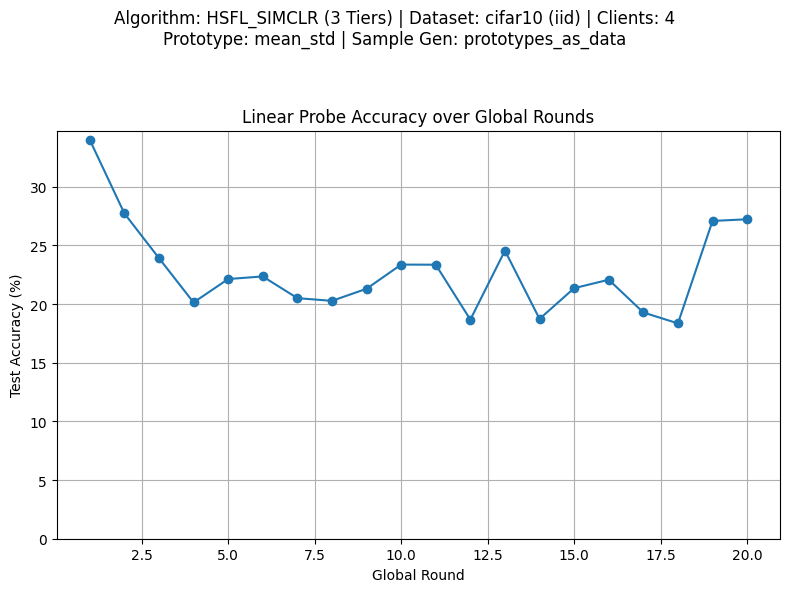

In [ ]:
# Cell 7: Trực quan hóa kết quả 📊
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
title = (f"Algorithm: {config.ALGORITHM.upper()} ({config.NUM_TIERS} Tiers) | Dataset: {data_params['dataset_name']} "
         f"({data_params['distribution_mode']}) | Clients: {total_num_clients}\n"
         f"Prototype: {config.PROTOTYPE_METHOD} | Sample Gen: {config.SAMPLE_GENERATION_METHOD}")
fig.suptitle(title, fontsize=12)
rounds = history['rounds']
ax.plot(rounds, history['accuracy'], marker='o')
ax.set_title("Linear Probe Accuracy over Global Rounds")
ax.set_xlabel("Global Round")
ax.set_ylabel("Test Accuracy (%)")
ax.grid(True)
ax.set_ylim(bottom=0)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()